In [34]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import re

In [16]:
ROOT_DIR = r"D:\implementation\p2psta\implementation\results"  
RUN_NAME = None  # 例如 "run_20250917_134512"; 设为 None 则按修改时间自动选最新的 run_*

def pick_run(root_dir: str, run_name: str | None = None) -> Path | None:
    root = Path(root_dir)
    if run_name:
        rd = root / run_name
        return rd if rd.exists() else None
    runs = sorted(
        [p for p in root.glob("run_*") if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )
    return runs[0] if runs else None

RUN_DIR = pick_run(ROOT_DIR, RUN_NAME)
print("Using RUN_DIR:", RUN_DIR)
if RUN_DIR is None:
    raise FileNotFoundError("No run_* folder found. ")

Using RUN_DIR: D:\implementation\p2psta\implementation\results\run_20250918_132147


### Parameters and Timings Explanation

- **[Global Config]**
  - `data.csv_path`: Path to the dataset file used for ingestion.
  - `data.max_ingest`: Maximum number of records to ingest (`None` means all records).

- **[SFC Config]**
  - `algorithm`: Space-filling curve used (`z3` = 3D Z-order).
  - `center_lat`: Reference latitude for distance-to-meter conversion.
  - `x_precision_m`, `y_precision_m`: Spatial resolution in meters for X (longitude) and Y (latitude).
  - `t_precision_s`: Temporal resolution in seconds.
  - `derived_bits`: Bit lengths (`lx`, `ly`, `lt`) used for encoding; `ring_m` is the total key length for the DHT ring.
  - `global_lat`, `global_lon`, `global_time`: Bounding box of the dataset in latitude, longitude, and time.

- **[Experiment Config]**
  - `stop_tail_bits`: Controls granularity of range decomposition; smaller values = finer ranges.
  - `merge_gap_keys`: Threshold for merging small gaps between ranges (to reduce fragmentation).
  - `max_ranges`: Maximum number of ranges allowed per query (`None` = unlimited).

- **[Metrics]**
  - `precise_hits`: Whether precise post-filtering of results is enabled.
  - `save_with_nodes`: Whether query results are saved with node-level details.

- **[Queries]**
  - Total number of queries run in the experiment.
  - Each query includes: name, spatial bounding box (`lat`, `lon`), and temporal window (`time`).

- **Timings**
  - `ingest_ms`: Time spent ingesting all data (milliseconds).
  - `query[<name>]_ms`: Execution time of each query in milliseconds.


In [17]:
params_path = Path(RUN_DIR) / "params.txt"
timings_path = Path(RUN_DIR) / "timings.txt"

with open(params_path, "r", encoding="utf-8") as f:
    params_text = f.read()

with open(timings_path, "r", encoding="utf-8") as f:
    timings_text = f.read()

print(params_text)
print('...')
print(timings_text)


[Global Config]
data.csv_path=geolife_clean.csv
data.max_ingest=None

[SFC Config]
algorithm=z3
center_lat=39.9
x_precision_m=100
y_precision_m=100
t_precision_s=600
derived_bits: lx=10 ly=10 lt=19 ring_m=39
global_lat=[39.5, 40.2] global_lon=[116, 116.8] global_time=[1175385600, 1356998400]

[Experiment Config]
stop_tail_bits=12
merge_gap_keys=4095
max_ranges=None

[Metrics]
precise_hits=Some(true)
save_with_nodes=Some(true)

[Queries] total=2
Q00: name=Some("forbidden_city"), lat=[39.906,39.923], lon=[116.386,116.411], time=[2008-06-01T03:00:00Z,2010-06-10T03:15:00Z]
Q01: name=Some("beijing"), lat=[39.5,40.2], lon=[116,116.8], time=[2008-05-10T22:00:00Z,2012-05-20T01:00:00Z]

...
ingest_ms=15921
query[forbidden_city]_ms=568
query[beijing]_ms=27064



### About node_distribution.csv
This file summarizes how data is distributed across nodes in the DHT ring.

- **pnode_idx**: Index of the node in the experiment (0-based).  
- **node_id**: Identifier of the node on the DHT ring.  
- **total_count**: Number of records stored on this node.  
- **min_key**: Smallest key value stored on this node.  
- **max_key**: Largest key value stored on this node.  
- **key_span** (derived): The difference between `max_key` and `min_key`, indicating the portion of key space covered by the node.

In [18]:
csv_path = Path(RUN_DIR) / "node_distribution.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"node_distribution.csv not found at: {csv_path}")

# 读取 CSV；把空白当作缺失值处理
df = pd.read_csv(
    csv_path,
    dtype={"pnode_idx": "Int64", "node_id": "Int64", "total_count": "Int64"},
    na_values=["", " ", "NA", "NaN"]
)

# 确保 min_key / max_key 为可空整型；缺失保持 NaN
for col in ["min_key", "max_key"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")

# 计算 key_span（max_key - min_key）；缺失用 0
df["key_span"] = (df["max_key"] - df["min_key"]).astype("Int64")
df["key_span"] = df["key_span"].fillna(0)


df.head() 




,pnode_idx,node_id,total_count,min_key,max_key,key_span
0,0,0,0,<NA>,<NA>,0
1,1,536870912,0,<NA>,<NA>,0
2,2,1073741824,0,<NA>,<NA>,0
3,3,1610612736,0,<NA>,<NA>,0
4,4,2147483648,0,<NA>,<NA>,0


### Figure 1: Records per node
This chart shows the total number of records (`total_count`) stored on each node.  
- **X-axis:** Node index (`pnode_idx`)  
- **Y-axis:** Number of records stored  
The purpose of this figure is to reveal how evenly the data records are distributed across nodes. A balanced distribution indicates good load balancing, while large differences suggest potential hotspots.


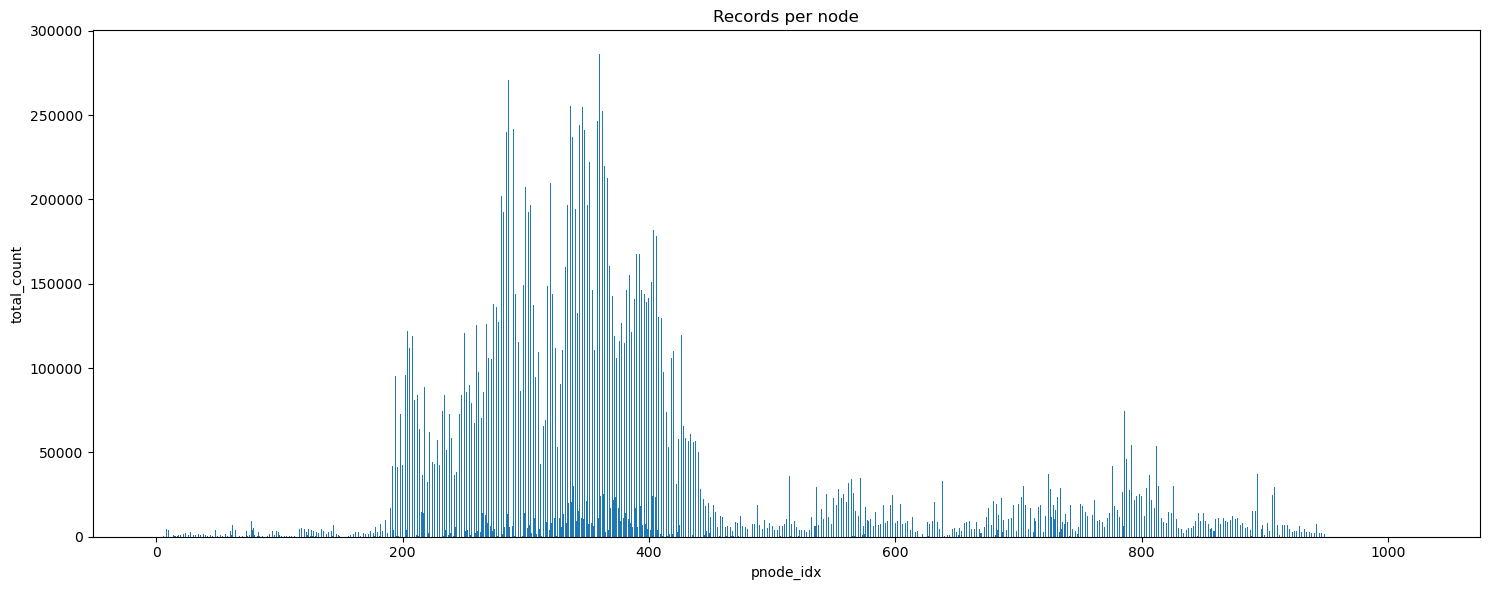

In [19]:
# --- 图1：每个 node 的 total_count ---
plt.figure(figsize=(15, 6))
plt.bar(df["pnode_idx"].fillna(0).astype(int), df["total_count"].fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("total_count")
plt.title("Records per node")
plt.tight_layout()
plt.show()


### Figure 2: Key span per node
This chart illustrates the key range assigned to each node, computed as `max_key - min_key`.  
- **X-axis:** Node index (`pnode_idx`)  
- **Y-axis:** Key span size  
This figure highlights how the key space is partitioned among the nodes. Large variations in span size imply that some nodes cover significantly larger portions of the key space, which may affect query routing and balance.


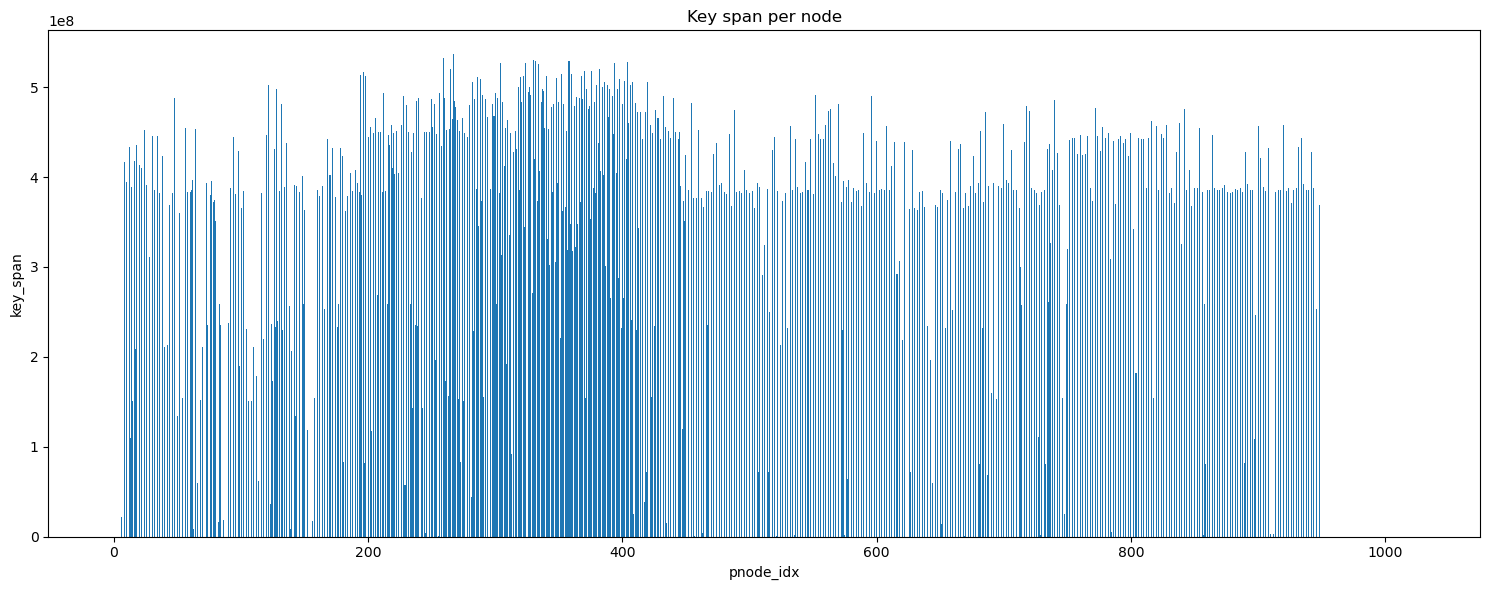

In [20]:
# --- 图2：每个 node 的 key_span（max_key - min_key）---
plt.figure(figsize=(15, 6))
plt.bar(df["pnode_idx"].fillna(0).astype(int), df["key_span"].fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("key_span")
plt.title("Key span per node")
plt.tight_layout()
plt.show()

### About nodes_dump.csv
This file lists all trajectory points stored on each node.

- **pnode_idx**: Index of the node where the record is stored.  
- **node_id**: Identifier of the node on the DHT ring.  
- **key**: Encoded SFC key of the point.  
- **user**: User ID to which the trajectory belongs.  
- **traj_id**: Identifier of the trajectory sequence.  
- **lat**: Latitude of the trajectory point.  
- **lon**: Longitude of the trajectory point.  
- **datetime**: Timestamp of the trajectory point (ISO-8601 format).


In [21]:
csv_path = Path(RUN_DIR) / "nodes_dump.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"nodes_dump.csv not found at: {csv_path}")

# 读取数据
df = pd.read_csv(
    csv_path,
    dtype={"pnode_idx": "Int64", "node_id": "Int64", "key": "Int64", "user": "Int64", "traj_id": "Int64"},
    parse_dates=["datetime"]
)

print("Rows:", len(df))
df.head(10)

Rows: 19632236


,pnode_idx,node_id,key,user,traj_id,lat,lon,datetime
0,6,3221225472,2863414244,142,6889738959171791553,39.948650,116.265983,2007-04-12 03:32:22+00:00
1,6,3221225472,2863414244,142,6889738959171791553,39.948433,116.265933,2007-04-12 03:32:44+00:00
2,6,3221225472,2863414244,142,6889738959171791553,39.948283,116.266017,2007-04-12 03:33:00+00:00
3,6,3221225472,2863414240,142,6889738959171791553,39.948167,116.266150,2007-04-12 03:33:40+00:00
4,6,3221225472,2863429161,142,6889738959171791553,39.950550,116.269100,2007-04-12 03:29:23+00:00
5,6,3221225472,2863428255,142,6889738959171791553,39.949800,116.268950,2007-04-12 03:29:30+00:00
6,6,3221225472,2863428251,142,6889738959171791553,39.949550,116.268800,2007-04-12 03:29:34+00:00
7,6,3221225472,2863428249,142,6889738959171791553,39.949500,116.267900,2007-04-12 03:29:46+00:00
8,6,3221225472,2863428290,142,6889738959171791553,39.949417,116.267267,2007-04-12 03:29:55+00:00
9,6,3221225472,2863428288,142,6889738959171791553,39.949450,116.266333,2007-04-12 03:30:05+00:00


### Figure 1: Trajectory points (scatter plot)
This scatter plot shows the geographic distribution of all trajectory points stored in the selected node dump.  
- **X-axis:** Longitude  
- **Y-axis:** Latitude  
The figure helps to visualize the spatial footprint of the stored data and check whether the points correspond to realistic trajectories.


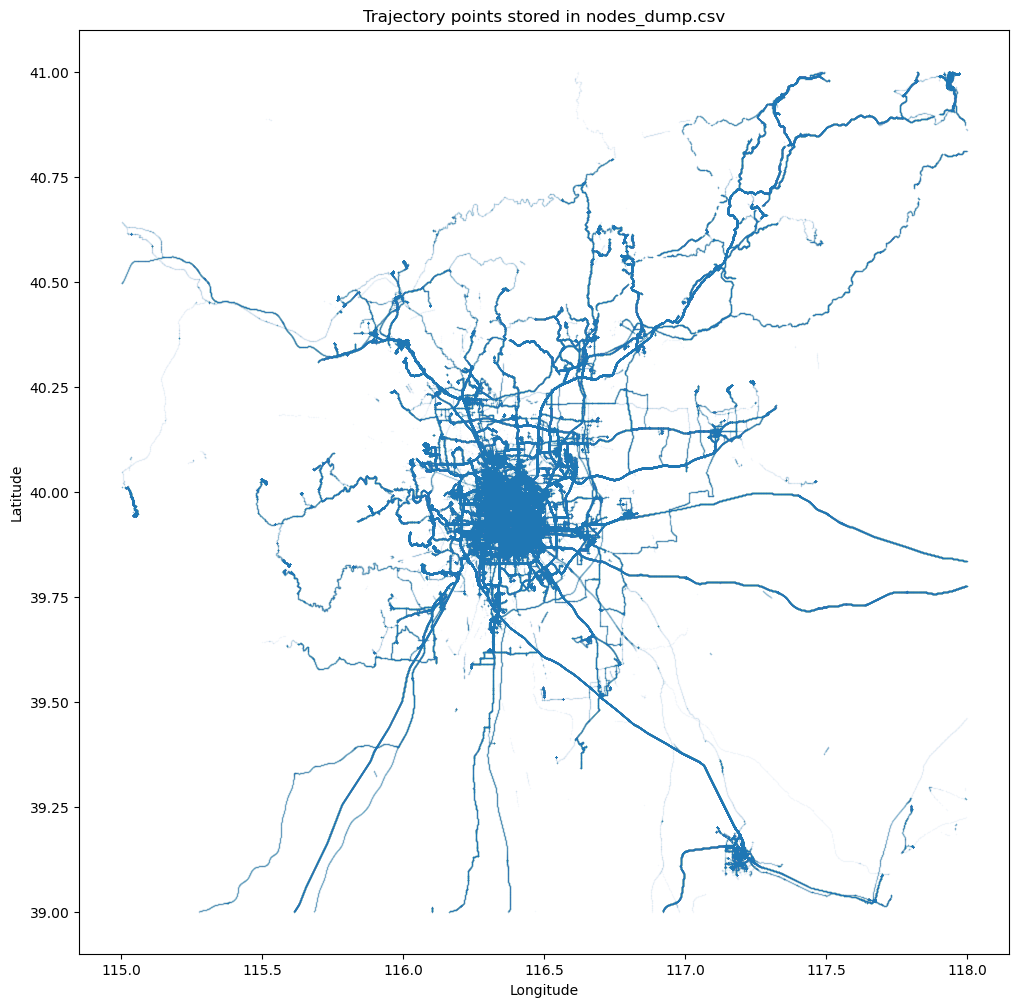

In [22]:
plt.figure(figsize=(12,12))
plt.scatter(df["lon"], df["lat"], s=1, alpha=0.05,linewidth=0)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Trajectory points stored in nodes_dump.csv")
plt.show()

### Figure 2: Trajectory timeline
This plot shows how latitude and longitude values evolve over time.  
- **X-axis:** Timestamp (`datetime`)  
- **Y-axis:** Latitude and Longitude values  
The figure helps to inspect the temporal continuity of trajectories and identify gaps or irregular sampling intervals.


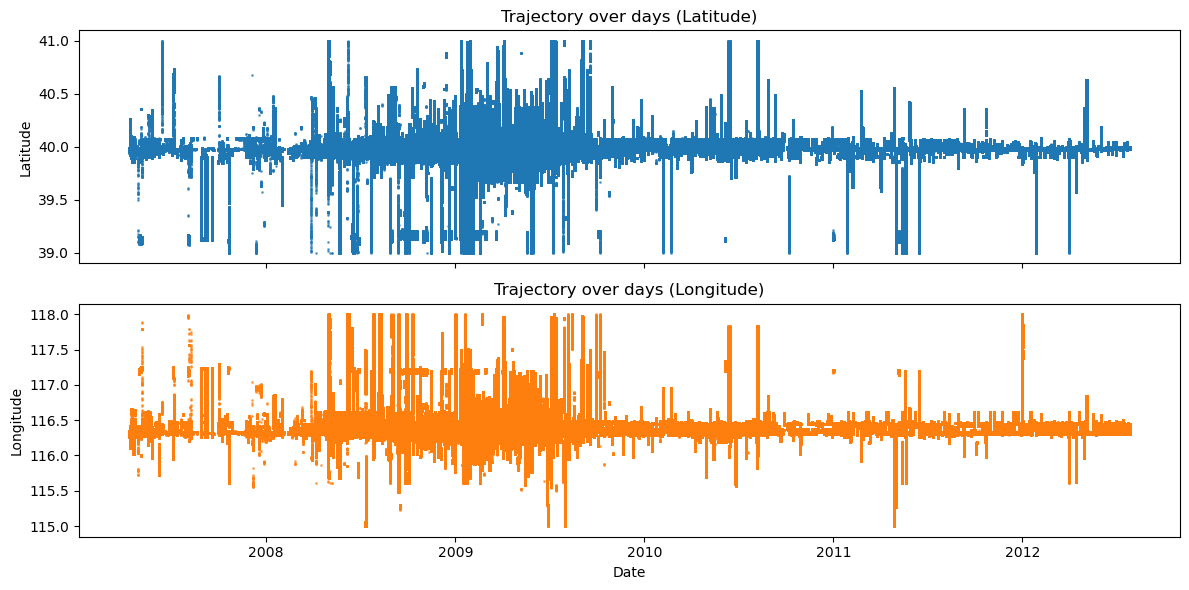

In [23]:
df["date"] = df["datetime"].dt.date  # 只取年月日

fig, axs = plt.subplots(2, 1, figsize=(12,6), sharex=True)

axs[0].plot(df["date"], df["lat"], ".", markersize=2, alpha=0.6, color="tab:blue")
axs[0].set_ylabel("Latitude")
axs[0].set_title("Trajectory over days (Latitude)")

axs[1].plot(df["date"], df["lon"], ".", markersize=2, alpha=0.6, color="tab:orange")
axs[1].set_ylabel("Longitude")
axs[1].set_xlabel("Date")
axs[1].set_title("Trajectory over days (Longitude)")

plt.tight_layout()
plt.show()

### Figure 3: Points per user
This bar chart shows the number of trajectory points stored for each user ID.  
- **X-axis:** User identifier (`user`)  
- **Y-axis:** Count of trajectory points  
The figure highlights how data is distributed across users, revealing whether some users dominate the dataset.


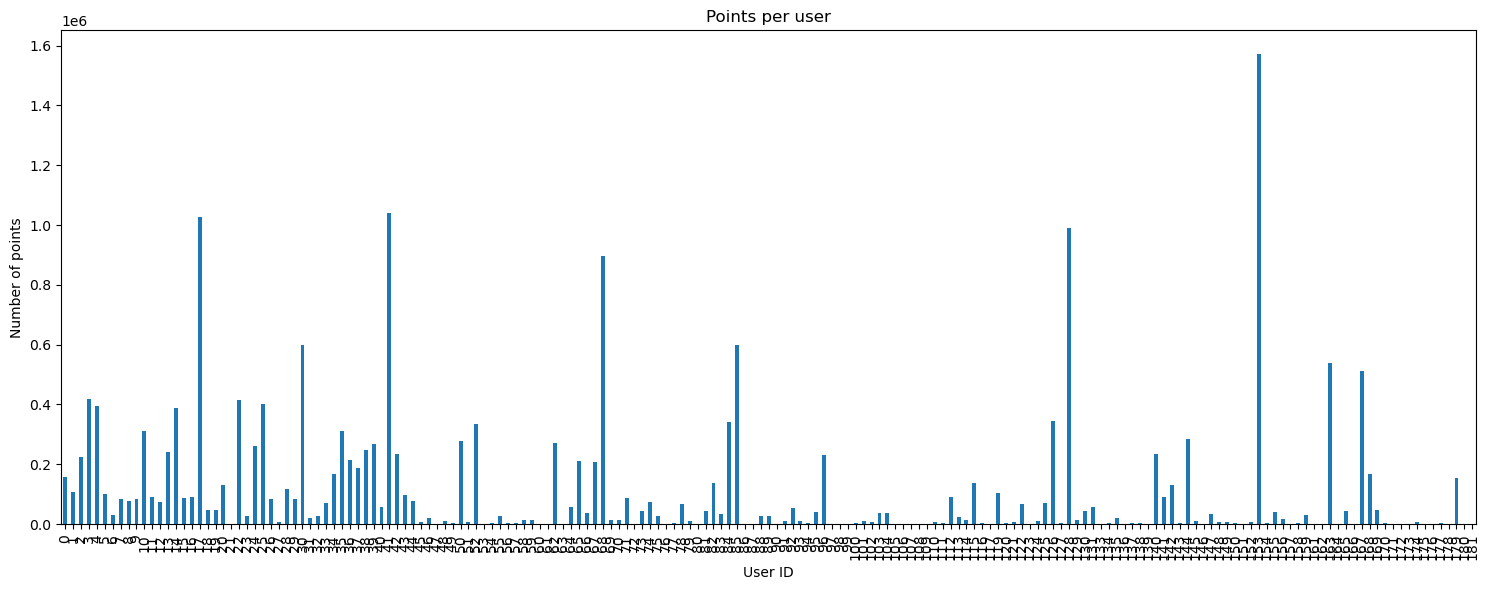

In [24]:
if "user" in df.columns:
    counts = df.groupby("user").size()
    counts.plot(kind="bar", figsize=(15,6))
    plt.xlabel("User ID")
    plt.ylabel("Number of points")
    plt.title("Points per user")
    plt.tight_layout()
    plt.show()

### About node_ranges.csv
This file describes each node's responsibility interval on the key ring and the data actually stored within that interval.

- **pnode_idx**: Index of the node in the experiment (0-based).
- **node_id**: Identifier of the node on the DHT ring.
- **resp_start**: Start of the responsibility interval on the ring (in key space).
- **resp_end**: End of the responsibility interval on the ring (in key space).
- **wrapped**: Whether the interval wraps around the zero point of the ring (if `true`, the interval is split across the end and the beginning of the ring).
- **stored_total**: Number of records actually stored on this node.
- **stored_min**: Minimum key of stored records on this node (if any).
- **stored_max**: Maximum key of stored records on this node (if any).

> Note: The ring size is `2^ring_m`, where `ring_m` is read from `params.txt`. The effective interval length is computed modulo the ring size.


In [25]:
csv_path = Path(RUN_DIR) / "node_ranges.csv"
if not csv_path.exists():
    raise FileNotFoundError(f"node_ranges.csv not found at: {csv_path}")

df = pd.read_csv(
    csv_path,
    dtype={
        "pnode_idx": "Int64",
        "node_id": "Int64",
        "resp_start": "Int64",
        "resp_end": "Int64",
        "stored_total": "Int64",
        "stored_min": "Int64",
        "stored_max": "Int64",
    },
    na_values=["", " ", "NA", "NaN"]
)

# 规范 wrapped 布尔列
if "wrapped" in df.columns:
    df["wrapped"] = df["wrapped"].astype(str).str.lower().map({"true": True, "false": False})
else:
    df["wrapped"] = False

# ---- 解析 ring_m（来自 params.txt），计算环长 ----
params_path = Path(RUN_DIR) / "params.txt"
if not params_path.exists():
    raise FileNotFoundError(f"params.txt not found at: {params_path} (needed to parse ring_m)")

params_text = params_path.read_text(encoding="utf-8", errors="ignore")
m = re.search(r"ring_m\s*=\s*(\d+)", params_text)
if not m:
    raise ValueError("Unable to parse ring_m from params.txt (expected like 'ring_m=39').")
ring_m = int(m.group(1))
ring_size = 1 << ring_m

print(f"ring_m = {ring_m}, ring_size = {ring_size}")

# ---- 计算责任跨度（模环长）----
# exclusive 跨度： (end - start) mod ring_size
resp_span_excl = (df["resp_end"].astype("Int64") - df["resp_start"].astype("Int64")) % ring_size
df["resp_span"] = resp_span_excl.astype("Int64")
# 也可以给出 inclusive 的跨度（+1），但作图用 resp_span 更直观
df["resp_span_inclusive"] = (df["resp_span"] + 1).astype("Int64")

# 存储区间跨度（若存在）
df["stored_span"] = (df["stored_max"] - df["stored_min"]).astype("Int64")
df["stored_span"] = df["stored_span"].fillna(0)

# 排序（按 pnode_idx）
df = df.sort_values("pnode_idx").reset_index(drop=True)
df.head()

ring_m = 39, ring_size = 549755813888


,pnode_idx,node_id,resp_start,resp_end,wrapped,stored_total,stored_min,stored_max,resp_span,resp_span_inclusive,stored_span
0,0,0,549218942977,0,True,0,<NA>,<NA>,536870911,536870912,0
1,1,536870912,1,536870912,False,0,<NA>,<NA>,536870911,536870912,0
2,2,1073741824,536870913,1073741824,False,0,<NA>,<NA>,536870911,536870912,0
3,3,1610612736,1073741825,1610612736,False,0,<NA>,<NA>,536870911,536870912,0
4,4,2147483648,1610612737,2147483648,False,0,<NA>,<NA>,536870911,536870912,0


### Figure 1: Stored records per node
This bar chart shows the number of records stored on each node (`stored_total`).
- **X-axis:** Node index (`pnode_idx`)
- **Y-axis:** Number of stored records
Use this figure to assess load balance. Significant differences may indicate hotspots or skewed placement.


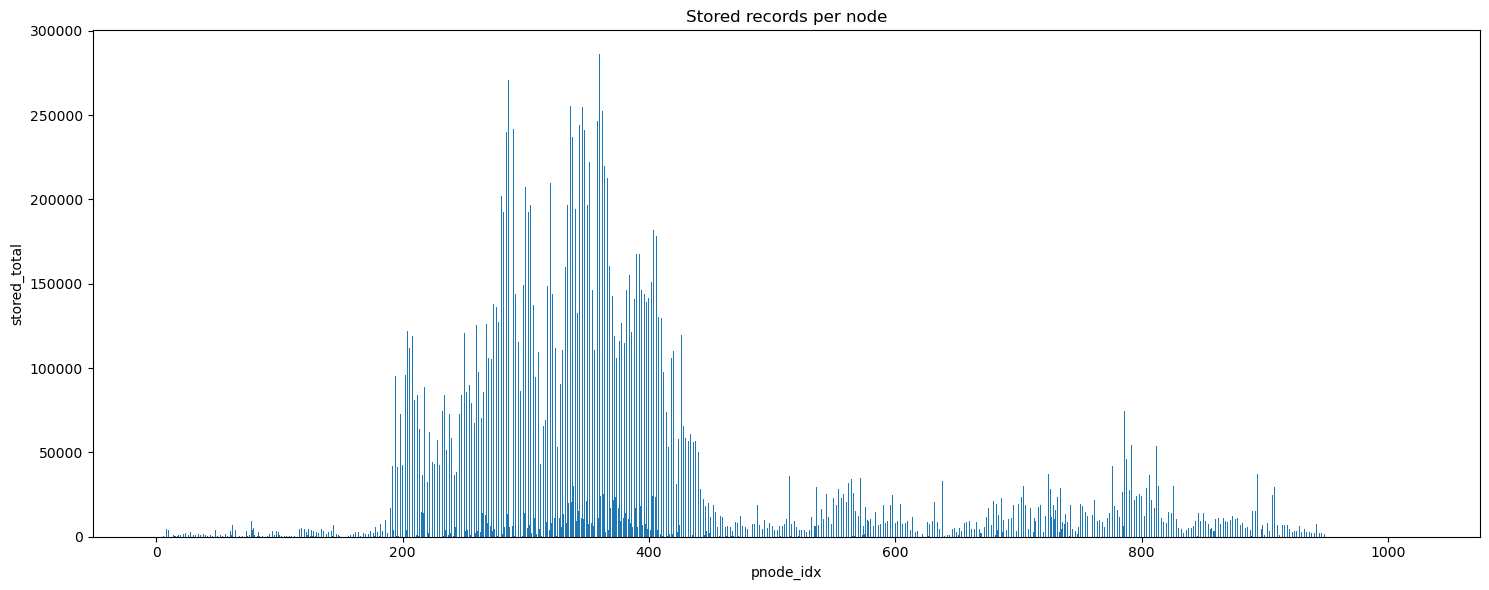

In [26]:
plt.figure(figsize=(15, 6))
plt.bar(df["pnode_idx"].astype(int), df["stored_total"].fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("stored_total")
plt.title("Stored records per node")
plt.tight_layout()
plt.show()

### Figure 2: Responsibility span per node
This bar chart shows the size of each node's responsibility interval on the ring, computed as `(resp_end - resp_start) mod ring_size`.
- **X-axis:** Node index (`pnode_idx`)
- **Y-axis:** Responsibility span (in key counts)
If some nodes cover much larger spans than others, the ring partitioning may be uneven, which can affect routing and load balance.


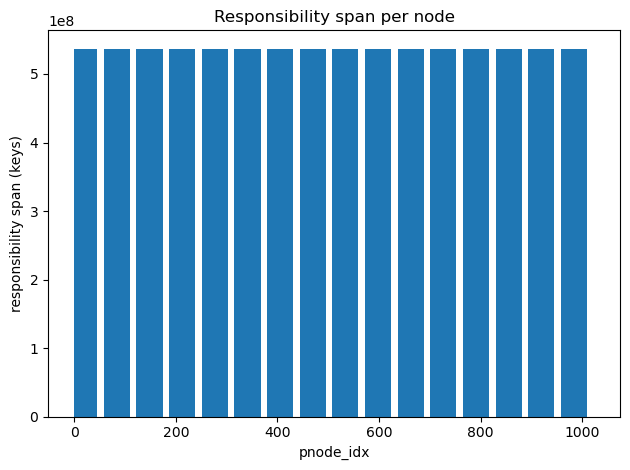

In [27]:
plt.figure()
plt.bar(df["pnode_idx"].astype(int), df["resp_span"].astype("Int64").fillna(0).astype(int))
plt.xlabel("pnode_idx")
plt.ylabel("responsibility span (keys)")
plt.title("Responsibility span per node")
plt.tight_layout()
plt.show()

### Figure 3: Responsibility ranges on the ring
This figure illustrates each node’s responsibility interval as a horizontal segment on the key ring. If an interval wraps around the ring’s zero point, it is drawn as two segments (from `resp_start` to the ring end, and from zero to `resp_end`).
- **X-axis:** Ring key
- **Y-axis:** Node index (`pnode_idx`)
This visualization helps validate that node intervals tile the ring without gaps or overlaps, and clarifies where wrapped intervals occur.

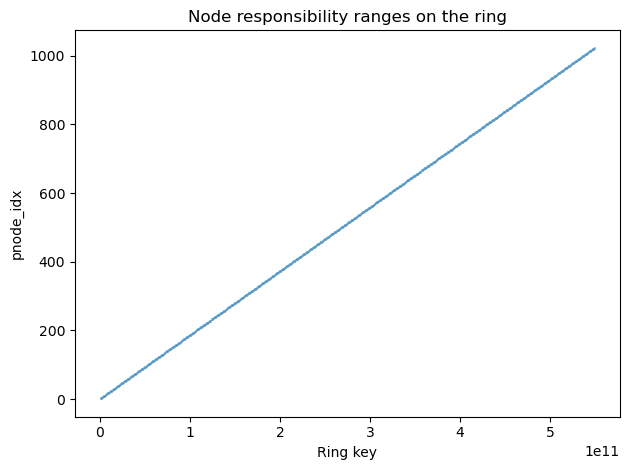

In [28]:
plt.figure()
y_vals = df["pnode_idx"].astype(int).tolist()
for _, r in df.iterrows():
    y = int(r["pnode_idx"])
    start = int(r["resp_start"])
    end = int(r["resp_end"])
    wrapped = bool(r["wrapped"])

    if not wrapped:
        # 普通情况： [start, end)
        plt.hlines(y=y, xmin=start, xmax=end, linewidth=2)
    else:
        # 跨零点：分两段 [start, ring_size) 和 [0, end)
        plt.hlines(y=y, xmin=start, xmax=ring_size, linewidth=2)
        plt.hlines(y=y, xmin=0, xmax=end, linewidth=2)

plt.xlabel("Ring key")
plt.ylabel("pnode_idx")
plt.title("Node responsibility ranges on the ring")
plt.tight_layout()
plt.show()

### Original data file

In [29]:
CSV_PATH = 'D:\implementation\p2psta\implementation\geolife_clean.csv' 
# ===== 1. 读数据 =====
df = pd.read_csv(
    CSV_PATH,
    parse_dates=['datetime'],
    dtype={'user': 'category'}
)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\i'
<>:1: SyntaxWarning: invalid escape sequence '\i'
C:\Users\yezhan\AppData\Local\Temp\ipykernel_21032\1541564178.py:1: SyntaxWarning: invalid escape sequence '\i'
  CSV_PATH = 'D:\implementation\p2psta\implementation\geolife_clean.csv'


,user,traj_id,lat,lon,datetime
0,000,000/20081023025304,39.984702,116.318417,2008-10-22 18:53:04+00:00
1,000,000/20081023025304,39.984683,116.318450,2008-10-22 18:53:10+00:00
2,000,000/20081023025304,39.984686,116.318417,2008-10-22 18:53:15+00:00
3,000,000/20081023025304,39.984688,116.318385,2008-10-22 18:53:20+00:00
4,000,000/20081023025304,39.984655,116.318263,2008-10-22 18:53:25+00:00


In [30]:
t_min, t_max = df.datetime.min(), df.datetime.max()
lat_min, lat_max = df.lat.min(), df.lat.max()
lon_min, lon_max = df.lon.min(), df.lon.max()

print(f'row : {len(df):,}')
print(f'Total days        : {(t_max - t_min).days + 1} days')
print(f'Time span      : {t_min}  ——  {t_max}')
print(f'Latitude range      : {lat_min:.6f}  –  {lat_max:.6f}')
print(f'Longitude range     : {lon_min:.6f}  –  {lon_max:.6f}')

row : 19,632,236
Total days        : 1933 days
Time span      : 2007-04-12 01:31:32+00:00  ——  2012-07-27 00:31:20+00:00
Latitude range      : 39.000000  –  40.999996
Longitude range     : 115.000173  –  117.999978


### Time distribution of data

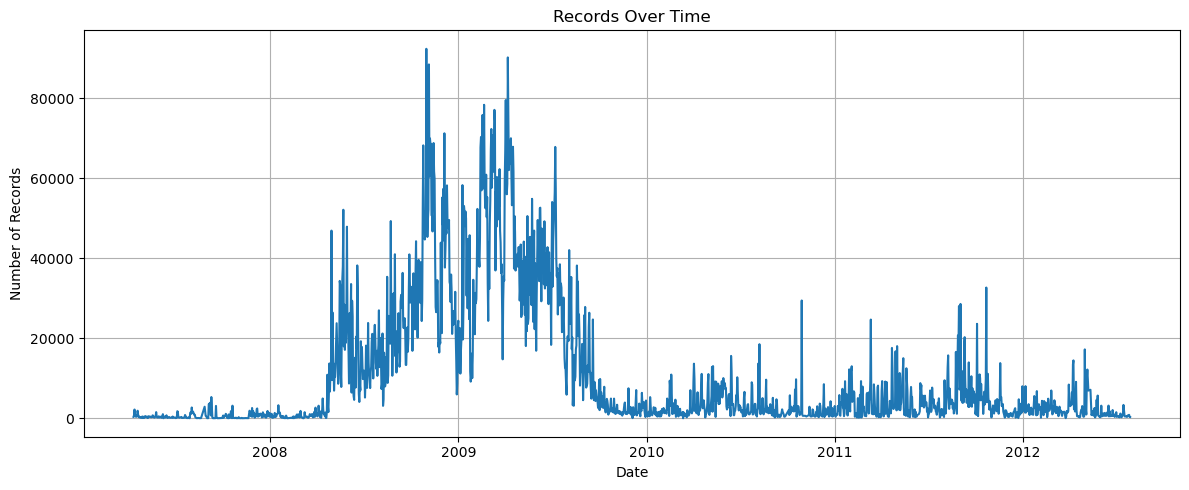

In [ ]:
df['date'] = df['datetime'].dt.date
date_counts = df['date'].value_counts().sort_index()
plt.figure(figsize=(12, 5))
plt.plot(date_counts.index, date_counts.values, linestyle='-')
plt.xlabel('Date')
plt.ylabel('Number of Records')
plt.title('Records Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

### Spatial distribution of data

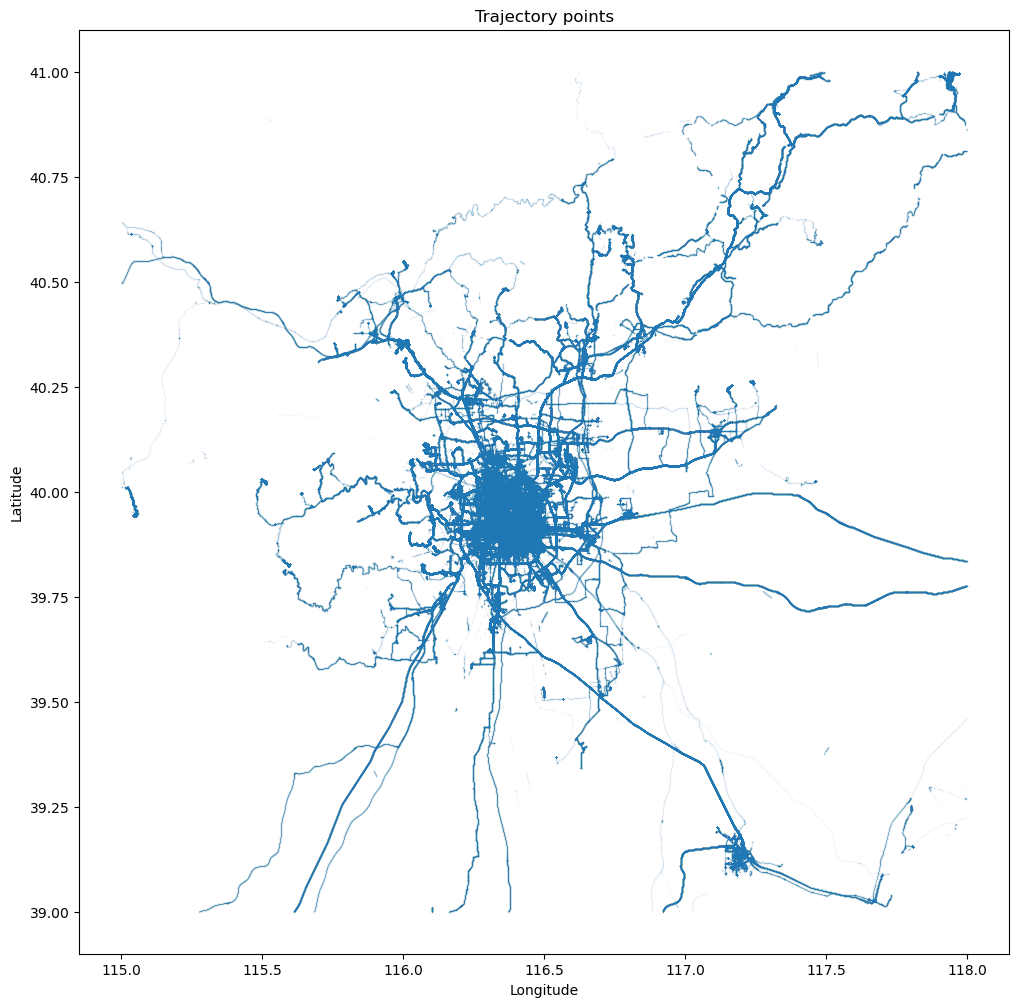

In [33]:
plt.figure(figsize=(12,12))
plt.scatter(df["lon"], df["lat"], s=1, alpha=0.05,linewidth=0)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Trajectory points")
plt.show()

#### The actual data within the query range in the original dataset

In [31]:
QUERIES = {
    'forbidden_city': {
        'lat_min': 39.906, 'lat_max': 39.923,
        'lon_min': 116.386, 'lon_max': 116.411,
        't_start': pd.Timestamp('2008-06-01 03:00:00', tz='UTC'),
        't_end': pd.Timestamp('2010-06-10 03:15:00', tz='UTC')
    },
    'beijing': {
        'lat_min': 39.5, 'lat_max': 40.2,
        'lon_min': 116.0, 'lon_max': 116.8,
        't_start': pd.Timestamp('2008-05-10 22:00:00', tz='UTC'),
        't_end': pd.Timestamp('2012-05-20 01:00:00', tz='UTC')
    }
}

def summarize(df, queries):
    """return dict：{query_name: {rows, users, trajs, first, last}}"""
    summary = {}
    for name, q in queries.items():
        mask = (
            (df.lat >= q['lat_min']) & (df.lat <= q['lat_max']) &
            (df.lon >= q['lon_min']) & (df.lon <= q['lon_max']) &
            (df.datetime >= q['t_start']) & (df.datetime <= q['t_end'])
        )
        sub = df[mask]
        summary[name] = {
            'rows': int(mask.sum()),
            'users': sub['user'].nunique(),
            'trajs': sub['traj_id'].nunique(),
            'first': sub['datetime'].min(),
            'last': sub['datetime'].max()
        }
    return summary

summary = summarize(df, QUERIES)
for name, s in summary.items():
    print(f"\n=== {name} ===")
    print(f"rows : {s['rows']}")
    print(f"users: {s['users']}")
    print(f"trajs: {s['trajs']}")
    print(f"time : {s['first']}  ~  {s['last']}")

# 顺便打印全表指标
print('\n=== full file ===')
print(f'total rows : {len(df)}')
print(f'total users: {df["user"].nunique()}')
print(f'total trajs: {df["traj_id"].nunique()}')
print(f'time range : {df["datetime"].min()}  ~  {df["datetime"].max()}')


=== forbidden_city ===
rows : 52649
users: 50
trajs: 216
time : 2008-06-05 01:45:44+00:00  ~  2010-06-04 03:13:41+00:00

=== beijing ===
rows : 17999400
users: 139
trajs: 15385
time : 2008-05-10 22:00:00+00:00  ~  2012-05-19 11:55:15+00:00

=== full file ===
total rows : 19632236
total users: 179
total trajs: 17314
time range : 2007-04-12 01:31:32+00:00  ~  2012-07-27 00:31:20+00:00


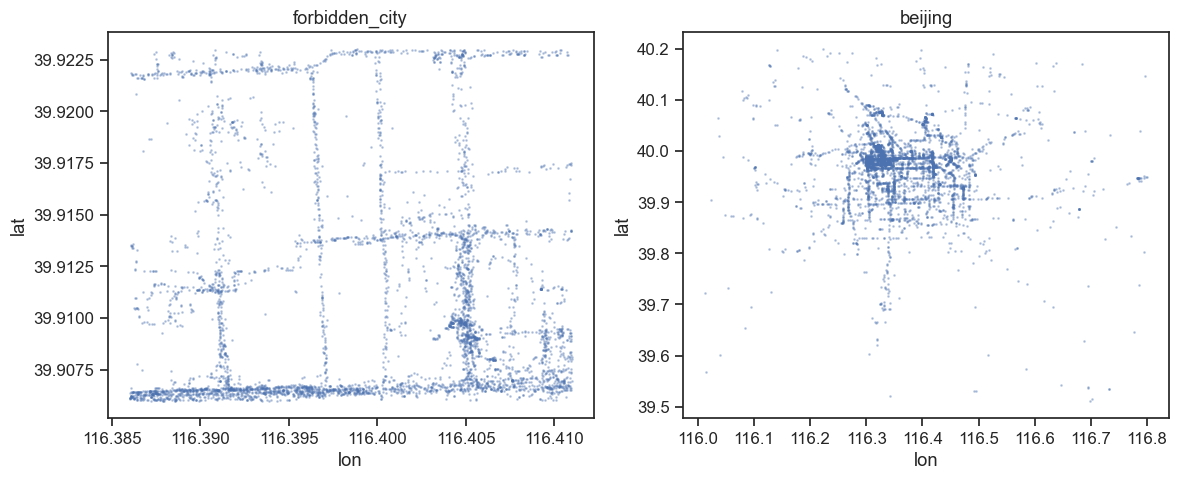

In [ ]:
sns.set(style="ticks", font_scale=1.1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, q) in zip(axes, QUERIES.items()):
    # 1. 先过滤
    mask = (
        (df.lat >= q['lat_min']) & (df.lat <= q['lat_max']) &
        (df.lon >= q['lon_min']) & (df.lon <= q['lon_max']) &
        (df.datetime >= q['t_start']) & (df.datetime <= q['t_end'])
    )
    sub = df[mask]                  
    if sub.empty:                        
        print(f'{name} no data in range, skipping plot.')
        continue
    # 4. 再抽样
    sub = sub.sample(n=min(5000, len(sub)), random_state=42)
    ax.scatter(sub.lon, sub.lat, s=1, alpha=0.3)
    ax.set_title(name)
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

plt.tight_layout()
plt.show()

#### Query results of project

In [44]:
queries = {
    "forbidden_city": Path(RUN_DIR) / "query_00_forbidden_city",
    "beijing":         Path(RUN_DIR) / "query_01_beijing",
}

files = {
    name: qdir / "query_results.csv"
    for name, qdir in queries.items()
}

dfs = {}
for name, path in files.items():
    df = pd.read_csv(
        path,
        parse_dates=['datetime'],
        dtype={'traj_id': str}
    )
    df['traj_id'] = df['traj_id'].str.strip()

    dfs[name] = df
    
summary = {}
for name, df in dfs.items():
    summary[name] = {
        'rows': len(df),
        'users': df['user'].nunique(),
        'trajs': df['traj_id'].nunique(),
        'first': df['datetime'].min(),
        'last': df['datetime'].max()
    }

for name, s in summary.items():
    print(f'\n=== {name} ===')
    print(f"rows : {s['rows']}")
    print(f"users: {s['users']}")
    print(f"trajs: {s['trajs']}")
    print(f"time : {s['first']}  ~  {s['last']}")


=== forbidden_city ===
rows : 52649
users: 50
trajs: 216
time : 2008-06-05 01:45:44+00:00  ~  2010-06-04 03:13:41+00:00

=== beijing ===
rows : 17999400
users: 139
trajs: 15385
time : 2008-05-10 22:00:00+00:00  ~  2012-05-19 11:55:15+00:00


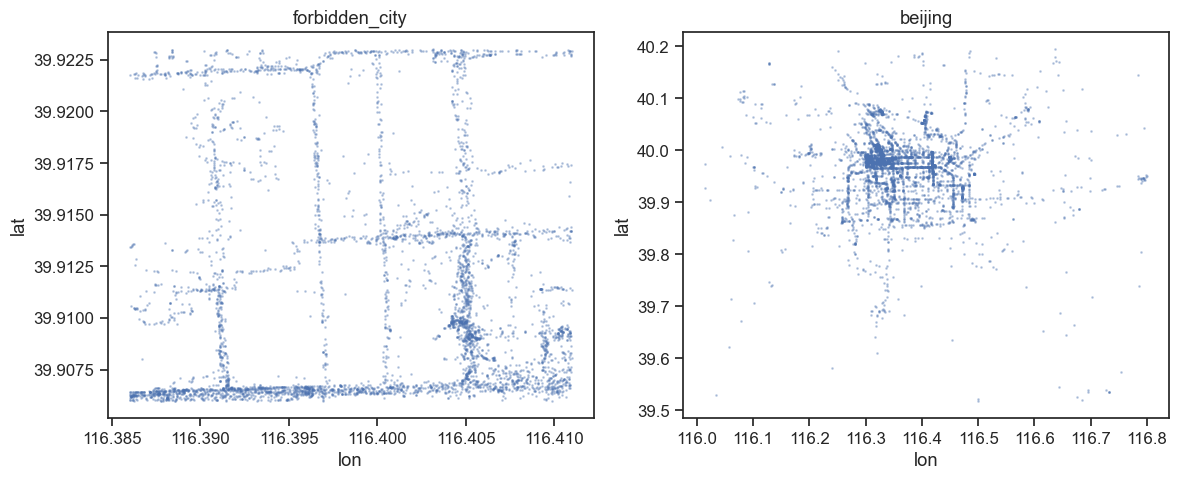

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, dfs.items()):
    if df.empty:
        ax.set_title(f'{name} 无数据')
        continue
    plot_df = df.sample(n=min(5000, len(df)), random_state=42)
    ax.scatter(plot_df.lon, plot_df.lat, s=1, alpha=0.3)
    ax.set_title(name)
    ax.set_xlabel('lon')
    ax.set_ylabel('lat')

plt.tight_layout()
plt.show()

### About ranges_and_hits_with_nodes.csv
This file lists every result row returned by the SFC range planner along with routing metadata.

- **range_idx**: The index of the SFC range that produced this row.  
- **pnode_idx**: Physical node index that contributed the row.  
- **node_id**: Node identifier in the DHT ring.  
- **sfc_key**: The SFC-encoded key associated with this row.  
- **traj_id**: Trajectory identifier of the source segment/point.  
- **segment_id**: Segment index within the trajectory (if applicable).  
- **ts**: Timestamp in epoch seconds.  
- **lat, lon**: Coordinates of the result point.  
- **route_hops**: Number of overlay hops the request took to reach the node.  
- **node_visits**: Number of nodes contacted/visited during the handling of this range (an indicator of request fan-out).


In [45]:
files = {
    name: qdir / "ranges_and_hits_with_nodes.csv"
    for name, qdir in queries.items()
}

# --- 读取为 DataFrame 字典 ---
dfs = {}
for name, path in files.items():
    if not path.exists():
        print(f"[WARN] {name}: file not found -> {path}")
        continue

    df = pd.read_csv(
        path,
        dtype={
            "range_idx": "Int64",
            "pnode_idx": "Int64",
            "node_id":   "Int64",
            "sfc_key":   "Int64",
            "traj_id":   "Int64",
            "segment_id":"Int64",
            "route_hops":"Int64",
            "node_visits":"Int64",
        },
        na_values=["", " ", "NA", "NaN"]
    )

    # ts -> datetime（UTC），并聚合到“天”
    df["ts"] = pd.to_numeric(df["ts"], errors="coerce").astype("Int64")
    df["datetime"] = pd.to_datetime(df["ts"], unit="s", utc=True)
    df["date"] = df["datetime"].dt.date

    # 经纬度
    df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
    df["lon"] = pd.to_numeric(df["lon"], errors="coerce")

    dfs[name] = df
    print(f"[OK] {name}: rows={len(df):,}, columns={list(df.columns)}")

# 若都不存在，直接返回
if not dfs:
    raise FileNotFoundError("No ranges_and_hits_with_nodes.csv found under query_* folders.")

[OK] forbidden_city: rows=52,649, columns=['range_idx', 'pnode_idx', 'node_id', 'sfc_key', 'traj_id', 'segment_id', 'ts', 'lat', 'lon', 'route_hops', 'node_visits', 'datetime', 'date']
[OK] beijing: rows=17,999,400, columns=['range_idx', 'pnode_idx', 'node_id', 'sfc_key', 'traj_id', 'segment_id', 'ts', 'lat', 'lon', 'route_hops', 'node_visits', 'datetime', 'date']


In [46]:
TOP_N = 30    # bar chart 显示前 N 名
MAX_SCATTER = 20000 

### Figure: Distribution of route_hops
A histogram of overlay hops (`route_hops`) observed in the results.
- **X-axis:** Hop count
- **Y-axis:** Number of rows
Lower hop counts generally indicate shorter overlay paths and lower routing latency.


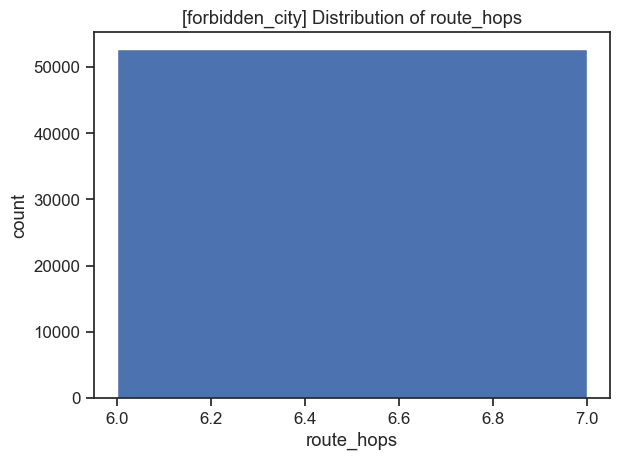

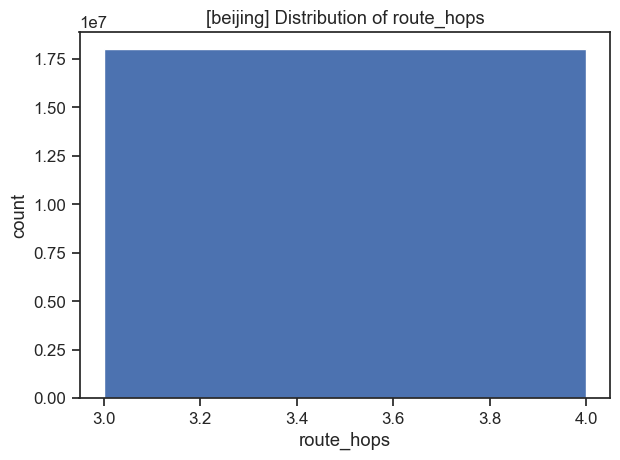

In [47]:
for name, df in dfs.items():
    if "route_hops" not in df.columns:
        continue
    hops = df["route_hops"].dropna().astype(int)
    if hops.empty:
        continue

    plt.figure()
    bins = np.arange(hops.min(), hops.max() + 2)  # 整数桶
    plt.hist(hops, bins=bins)
    plt.xlabel("route_hops")
    plt.ylabel("count")
    plt.title(f"[{name}] Distribution of route_hops")
    plt.tight_layout()
    plt.show()

### Figure: Distribution of node_visits
A histogram of `node_visits`, i.e., how many nodes were involved when serving a range.
- **X-axis:** Nodes visited
- **Y-axis:** Number of rows
Higher values suggest broader fan-out, which can increase network and coordination cost.


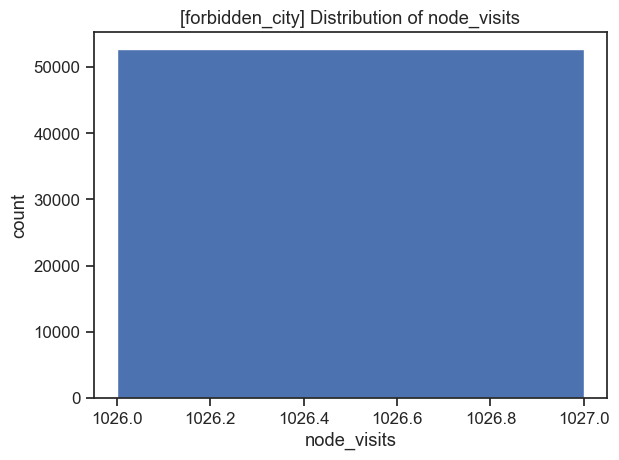

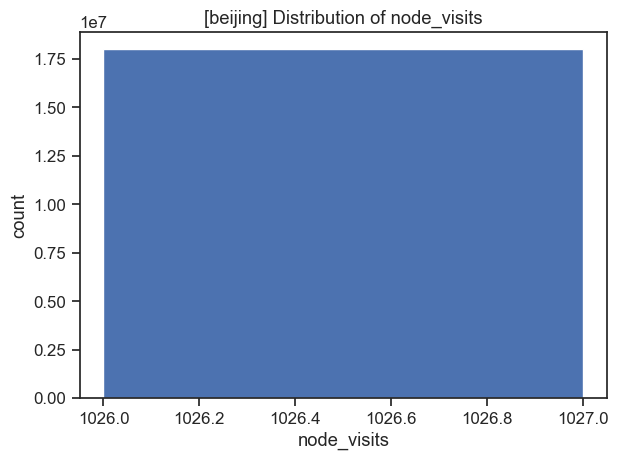

In [48]:
for name, df in dfs.items():
    if "node_visits" not in df.columns:
        continue
    vis = df["node_visits"].dropna().astype(int)
    if vis.empty:
        continue

    plt.figure()
    bins = np.arange(vis.min(), vis.max() + 2)
    plt.hist(vis, bins=bins)
    plt.xlabel("node_visits")
    plt.ylabel("count")
    plt.title(f"[{name}] Distribution of node_visits")
    plt.tight_layout()
    plt.show()

### Figure: Top ranges by hits
A bar chart showing the ranges (`range_idx`) that produced the most rows.
- **X-axis:** Range index (Top-N)
- **Y-axis:** Number of rows (hits)
This reveals which SFC ranges dominate the result volume, useful for hotspot analysis.


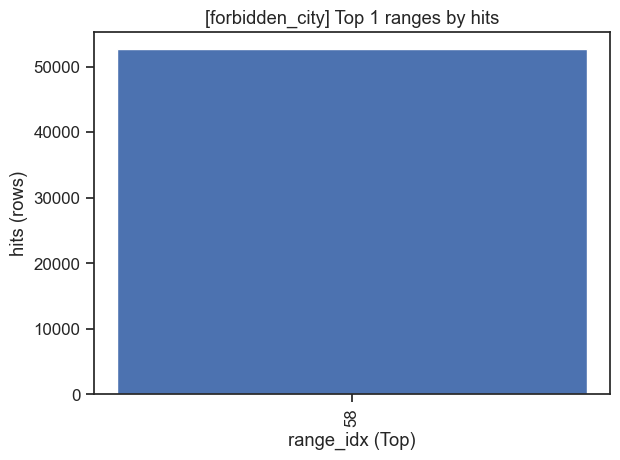

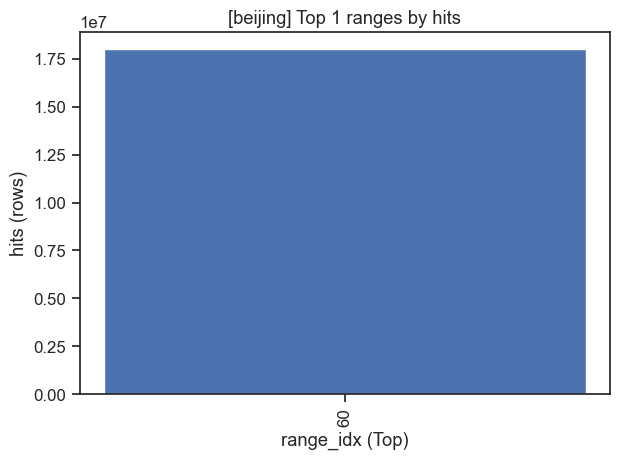

In [49]:
for name, df in dfs.items():
    grp = df.groupby("range_idx").size().sort_values(ascending=False)
    if grp.empty:
        continue
    top = grp.head(TOP_N)

    plt.figure()
    plt.bar(top.index.astype(int).astype(str), top.values.astype(int))
    plt.xlabel("range_idx (Top)")
    plt.ylabel("hits (rows)")
    plt.title(f"[{name}] Top {len(top)} ranges by hits")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Figure: Distribution of node cover across ranges
A histogram of the number of distinct nodes touched per range (`nunique(pnode_idx)`).
- **X-axis:** Nodes touched per range
- **Y-axis:** Number of ranges
Lower node cover is preferable as it reduces cross-node coordination during query processing.


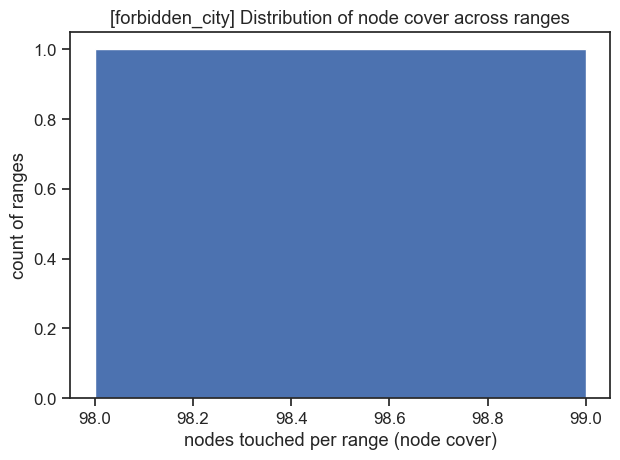

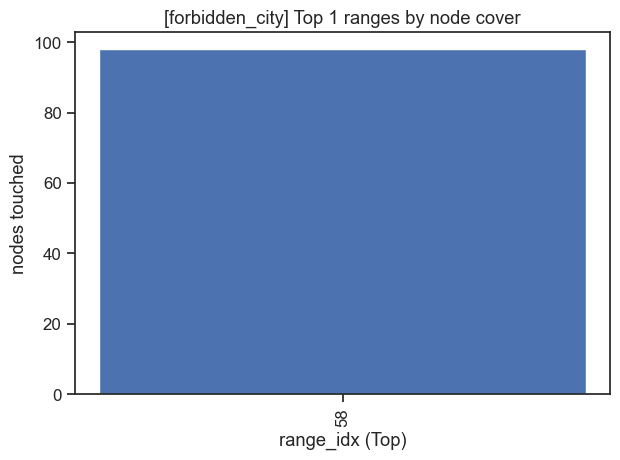

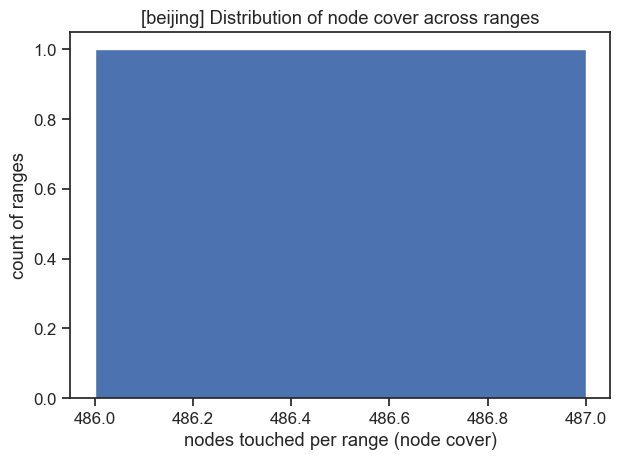

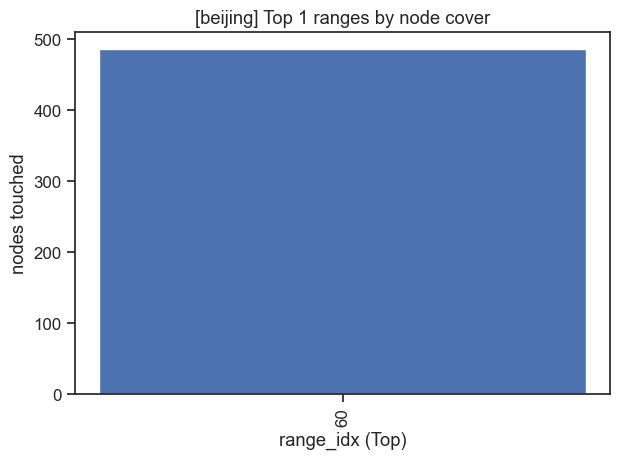

In [50]:
for name, df in dfs.items():
    cover = df.groupby("range_idx")["pnode_idx"].nunique().sort_values(ascending=False)
    if cover.empty:
        continue

    # 直方图看分布
    plt.figure()
    plt.hist(cover.values, bins=np.arange(cover.min(), cover.max() + 2))
    plt.xlabel("nodes touched per range (node cover)")
    plt.ylabel("count of ranges")
    plt.title(f"[{name}] Distribution of node cover across ranges")
    plt.tight_layout()
    plt.show()

    # Top N 的 node cover（柱状）
    top_cov = cover.head(TOP_N)
    plt.figure()
    plt.bar(top_cov.index.astype(int).astype(str), top_cov.values.astype(int))
    plt.xlabel("range_idx (Top)")
    plt.ylabel("nodes touched")
    plt.title(f"[{name}] Top {len(top_cov)} ranges by node cover")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Figure: Top pnodes by contributions
A bar chart of physical nodes contributing the most rows.
- **X-axis:** pnode index (Top-N)
- **Y-axis:** Number of rows
Skew here may indicate imbalance or data locality issues.


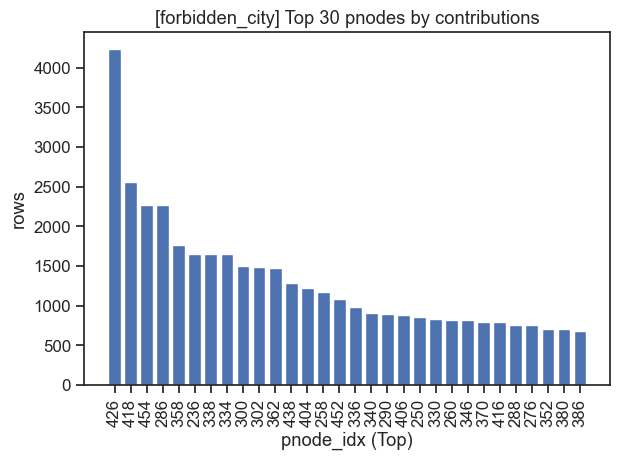

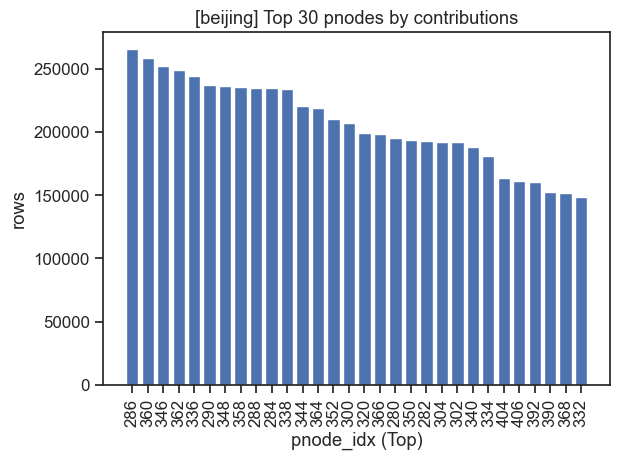

In [51]:
for name, df in dfs.items():
    by_node = df.groupby("pnode_idx").size().sort_values(ascending=False)
    if by_node.empty:
        continue
    top_nodes = by_node.head(TOP_N)

    plt.figure()
    plt.bar(top_nodes.index.astype(int).astype(str), top_nodes.values.astype(int))
    plt.xlabel("pnode_idx (Top)")
    plt.ylabel("rows")
    plt.title(f"[{name}] Top {len(top_nodes)} pnodes by contributions")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

### Figure: Daily hits (aggregated by day)
A time series of result counts aggregated at the day level.
- **X-axis:** Date
- **Y-axis:** Rows per day
Using days as the time unit avoids over-plotting and highlights broader temporal trends.


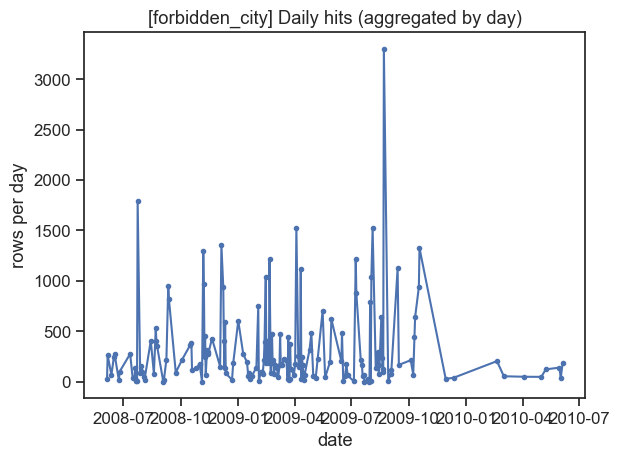

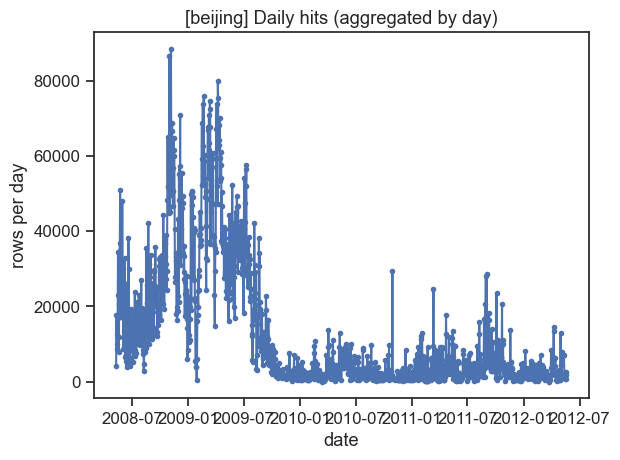

In [52]:
for name, df in dfs.items():
    if "date" not in df.columns:
        continue
    daily = df.groupby("date").size().sort_index()

    plt.figure()
    plt.plot(daily.index, daily.values, marker=".")
    plt.xlabel("date")
    plt.ylabel("rows per day")
    plt.title(f"[{name}] Daily hits (aggregated by day)")
    plt.tight_layout()
    plt.show()

### Figure: Spatial scatter
A scatter plot of longitude vs. latitude for the results (downsampled if too large).
- **X-axis:** Longitude
- **Y-axis:** Latitude
This figure shows the spatial footprint of the returned points and helps validate spatial coverage.


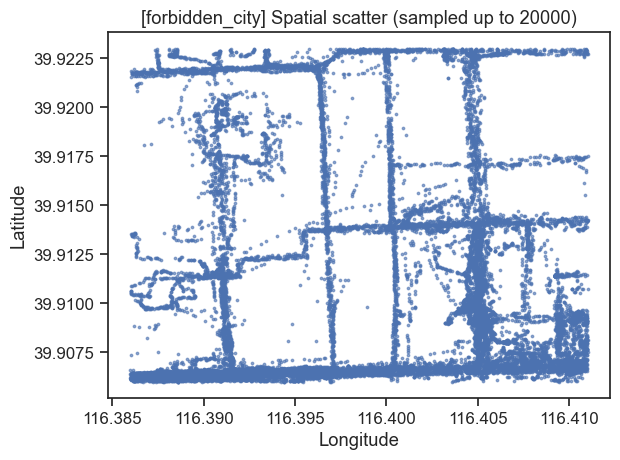

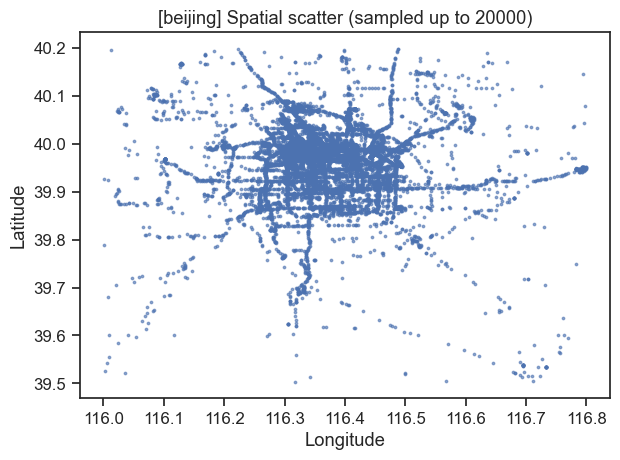

In [53]:
for name, df in dfs.items():
    coords = df[["lon", "lat"]].dropna()
    if coords.empty:
        continue
    if len(coords) > MAX_SCATTER:
        coords = coords.sample(MAX_SCATTER, random_state=0)

    plt.figure()
    plt.scatter(coords["lon"], coords["lat"], s=3, alpha=0.6)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"[{name}] Spatial scatter (sampled up to {MAX_SCATTER})")
    plt.tight_layout()
    plt.show()